# World Bank WDI — Exploratory Data Analysis
**Author : Shankha Roy** 
**Version: 1.0.0 — Created: 2026-04-11**

---

This notebook performs comprehensive EDA on the World Bank WDI panel dataset produced by the `wdi_etl` pipeline.

## Contents

1. [Setup & Data Loading](#1-setup)  
2. [Panel Overview](#2-overview)  
3. [Summary Statistics](#3-summary)  
4. [Missing-Value Analysis](#4-missingness)  
5. [Coverage by Country](#5-coverage-country)  
6. [Coverage by Year](#6-coverage-year)  
7. [Indicator Correlation Matrix](#7-correlation)  
8. [Distribution Analysis](#8-distribution)  
9. [Top & Bottom Countries](#9-top-bottom)  
10. [Time-Series Visualisation](#10-timeseries)  

---

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Setup & Data Loading
# ─────────────────────────────────────────────────────────────────────────────

import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

# Add parent directory to path so we can import wdi_etl as a package
sys.path.insert(0, str(Path("../").resolve()))

from wdi_etl.eda import (
    load_panel,
    summary_stats,
    missingness_report,
    missingness_heatmap_data,
    coverage_by_country,
    coverage_by_year,
    indicator_correlation,
    distribution_by_indicator,
    top_bottom,
    time_series_data,
    INDICATOR_LABELS,
)

# Plot styling
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Environment ready.")

Environment ready.


In [4]:
# Load the panel — automatically detects CSV or Parquet
PANEL_PATH = Path("../data/output/wdi_panel.csv")
df = load_panel(PANEL_PATH)
print(f"Panel shape : {df.shape}")
print(f"Columns     : {df.columns.tolist()}")
df.head(10)

Panel shape : (11817, 5)
Columns     : ['country_iso3', 'country_name', 'year', 'value', 'indicator_code']


,country_iso3,country_name,year,value,indicator_code
0,AFE,Africa Eastern and Southern,2023,27.8,IT.NET.USER.ZS
1,AFE,Africa Eastern and Southern,2022,26.8,IT.NET.USER.ZS
2,AFE,Africa Eastern and Southern,2021,25.0,IT.NET.USER.ZS
3,AFE,Africa Eastern and Southern,2020,23.5,IT.NET.USER.ZS
4,AFE,Africa Eastern and Southern,2019,21.6,IT.NET.USER.ZS
5,AFE,Africa Eastern and Southern,2018,19.6,IT.NET.USER.ZS
6,AFE,Africa Eastern and Southern,2017,17.3,IT.NET.USER.ZS
7,AFE,Africa Eastern and Southern,2016,16.3,IT.NET.USER.ZS
8,AFE,Africa Eastern and Southern,2015,14.3,IT.NET.USER.ZS
9,AFE,Africa Eastern and Southern,2014,12.1,IT.NET.USER.ZS


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Panel Overview
# ─────────────────────────────────────────────────────────────────────────────

n_countries   = df["country_iso3"].nunique()
n_years       = df["year"].nunique()
n_indicators  = df["indicator_code"].nunique()
n_observations= len(df)

print(f"Countries    : {n_countries}")
print(f"Years        : {sorted(df['year'].unique())}")
print(f"Year range   : {df['year'].min()} – {df['year'].max()}")
print(f"Indicators   : {n_indicators}")
print(f"Total rows   : {n_observations:,}")
print(f"Missing vals : {df['value'].isna().sum():,}")

# dtypes
df.dtypes

Countries    : 255
Years        : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Year range   : 2014 – 2023
Indicators   : 5
Total rows   : 11,817
Missing vals : 0


country_iso3       object
country_name       object
year                int64
value             float64
indicator_code     object
dtype: object

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Summary Statistics
# ─────────────────────────────────────────────────────────────────────────────

stats = summary_stats(df)
stats

,n_obs,mean,std,min,q25,median,q75,max,null
indicator_code,,,,,,,,,
IT.NET.USER.ZS,2153.0,57.38,28.36,0.99,31.50,63.22,81.71,100.00,397
NY.GDP.PCAP.CD,2481.0,17716.81,26664.21,232.94,2322.89,6665.74,21912.15,256799.79,69
NY.GNP.PCAP.CD,2387.0,15200.77,20346.01,240.00,2220.00,6199.06,19080.00,134500.00,163
SL.TLF.CACT.FE.ZS,2246.0,50.26,14.94,4.75,44.02,52.15,59.50,83.41,304
SP.URB.TOTL.IN.ZS,2550.0,60.45,22.61,13.13,42.48,61.00,78.75,100.00,0


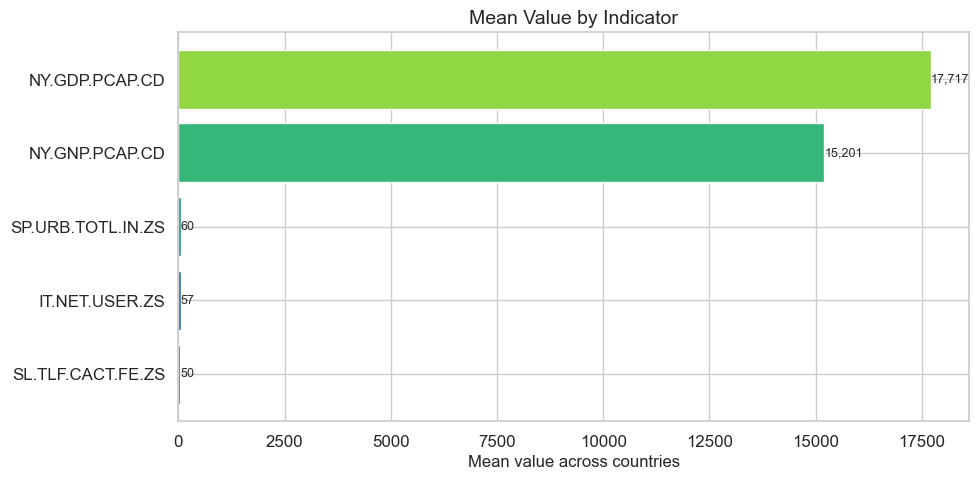

In [7]:
# Bar chart — mean value per indicator
fig, ax = plt.subplots(figsize=(10, 5))
means = stats["mean"].sort_values(ascending=True)
colors = sns.color_palette("viridis", len(means))
bars = ax.barh(means.index, means.values, color=colors)
ax.set_xlabel("Mean value across countries")
ax.set_title("Mean Value by Indicator")
for bar, val in zip(bars, means.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Missing-Value Analysis
# ─────────────────────────────────────────────────────────────────────────────

miss = missingness_report(df)
miss

,total_cells,non_null,null_count,missing_ratio
indicator_code,,,,
IT.NET.USER.ZS,2550,2153,397,0.1557
SL.TLF.CACT.FE.ZS,2550,2246,304,0.1192
NY.GNP.PCAP.CD,2550,2387,163,0.0639
NY.GDP.PCAP.CD,2550,2481,69,0.0271
SP.URB.TOTL.IN.ZS,2550,2550,0,0.0000


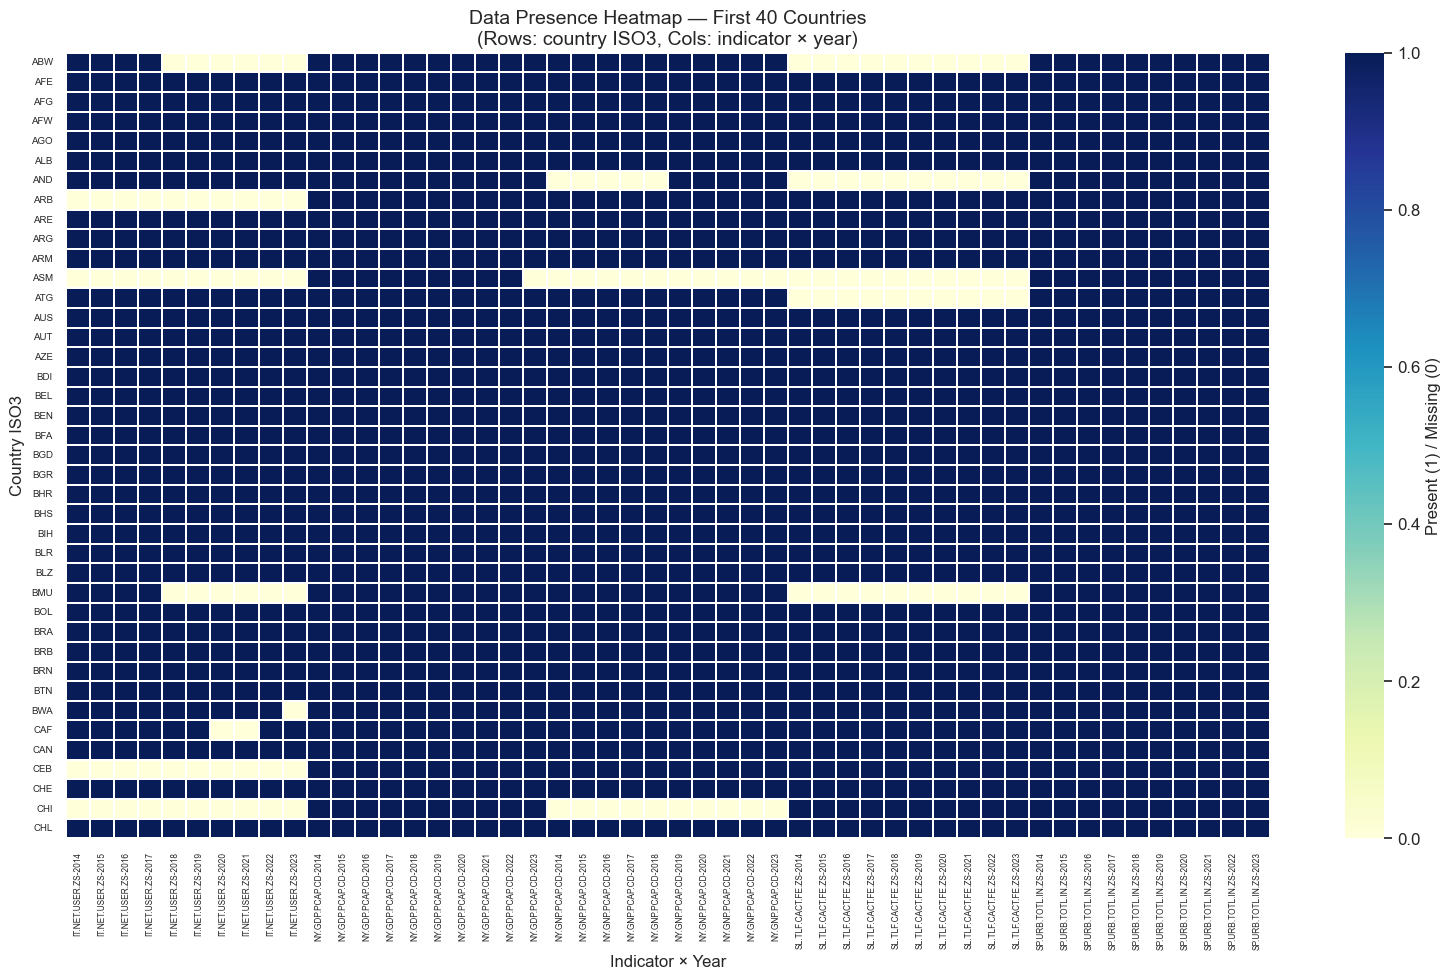

In [9]:
# Heatmap: non-null presence per indicator × year
heatmap_df = missingness_heatmap_data(df)

# Select a subset of countries for readability in the notebook
SAMPLE_COUNTRIES = 40
heatmap_sample = heatmap_df.head(SAMPLE_COUNTRIES)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    heatmap_sample,
    cmap="YlGnBu",
    cbar_kws={"label": "Present (1) / Missing (0)"},
    linewidths=0.1,
    linecolor="white",
    ax=ax,
)
ax.set_title(
    f"Data Presence Heatmap — First {SAMPLE_COUNTRIES} Countries\n"
    "(Rows: country ISO3, Cols: indicator × year)"
)
ax.set_xlabel("Indicator × Year")
ax.set_ylabel("Country ISO3")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Coverage by Country
# ─────────────────────────────────────────────────────────────────────────────

country_cov = coverage_by_country(df)
print(f"Well-covered countries (>= 5 obs per indicator): "
      f"{country_cov['is_well_covered'].sum()} / {len(country_cov)}")

country_cov.head(20)

Well-covered countries (>= 5 obs per indicator): 255 / 255


,country_iso3,country_name,n_indicators_with_data,n_years_with_data,n_total_obs,is_well_covered
0,LBR,Liberia,5,10,50,True
1,LVA,Latvia,5,10,50,True
2,MAR,Morocco,5,10,50,True
3,MDA,Moldova,5,10,50,True
4,MDG,Madagascar,5,10,50,True
5,MDV,Maldives,5,10,50,True
6,MEA,"Middle East, North Africa, Afghanistan & Pakistan",5,10,50,True
7,MEX,Mexico,5,10,50,True
8,MKD,North Macedonia,5,10,50,True
9,MLI,Mali,5,10,50,True


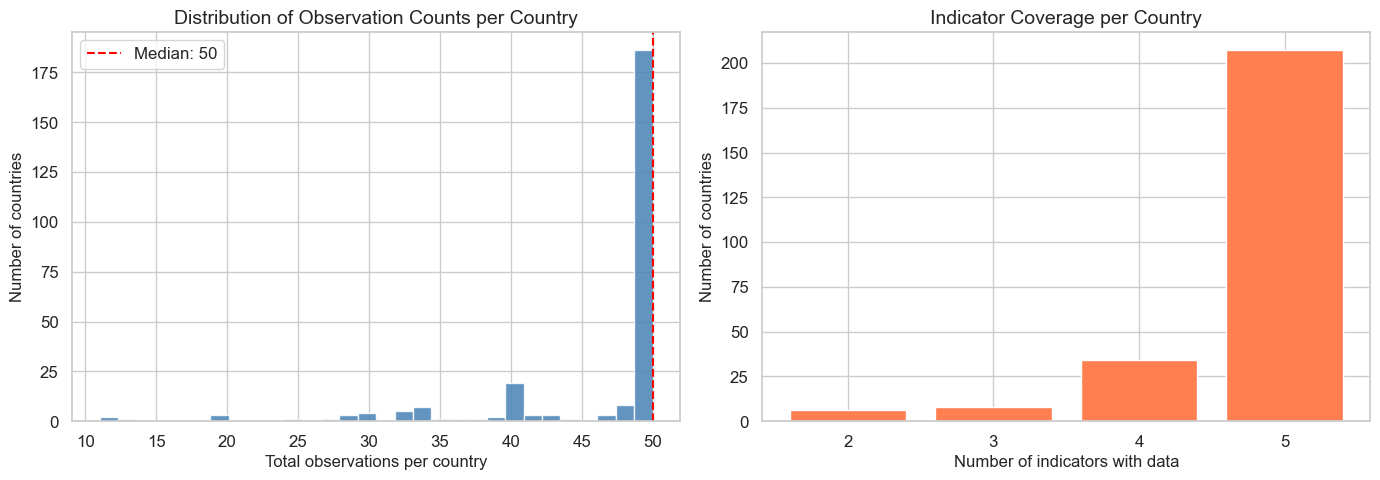

In [11]:
# Distribution of observation counts across countries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of total observations per country
axes[0].hist(country_cov["n_total_obs"], bins=30, color="steelblue",
             edgecolor="white", alpha=0.85)
axes[0].axvline(country_cov["n_total_obs"].median(), color="red",
                linestyle="--", label=f"Median: {country_cov['n_total_obs'].median():.0f}")
axes[0].set_xlabel("Total observations per country")
axes[0].set_ylabel("Number of countries")
axes[0].set_title("Distribution of Observation Counts per Country")
axes[0].legend()

# Right: bar — indicators covered per country
ind_per_country = country_cov["n_indicators_with_data"].value_counts().sort_index()
axes[1].bar(ind_per_country.index.astype(str), ind_per_country.values,
           color="coral", edgecolor="white")
axes[1].set_xlabel("Number of indicators with data")
axes[1].set_ylabel("Number of countries")
axes[1].set_title("Indicator Coverage per Country")

plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. Coverage by Year
# ─────────────────────────────────────────────────────────────────────────────

year_cov = coverage_by_year(df)
year_cov

indicator_code,IT.NET.USER.ZS,NY.GDP.PCAP.CD,NY.GNP.PCAP.CD,SL.TLF.CACT.FE.ZS,SP.URB.TOTL.IN.ZS,total_indicators_reported
year,,,,,,
2014,226,251,238,225,255,5
2015,226,250,239,225,255,5
2016,228,249,238,225,255,5
2017,225,249,239,225,255,5
2018,207,249,239,225,255,5
2019,214,249,240,225,255,5
2020,209,248,239,225,255,5
2021,205,248,239,225,255,5
2022,207,247,239,224,255,5


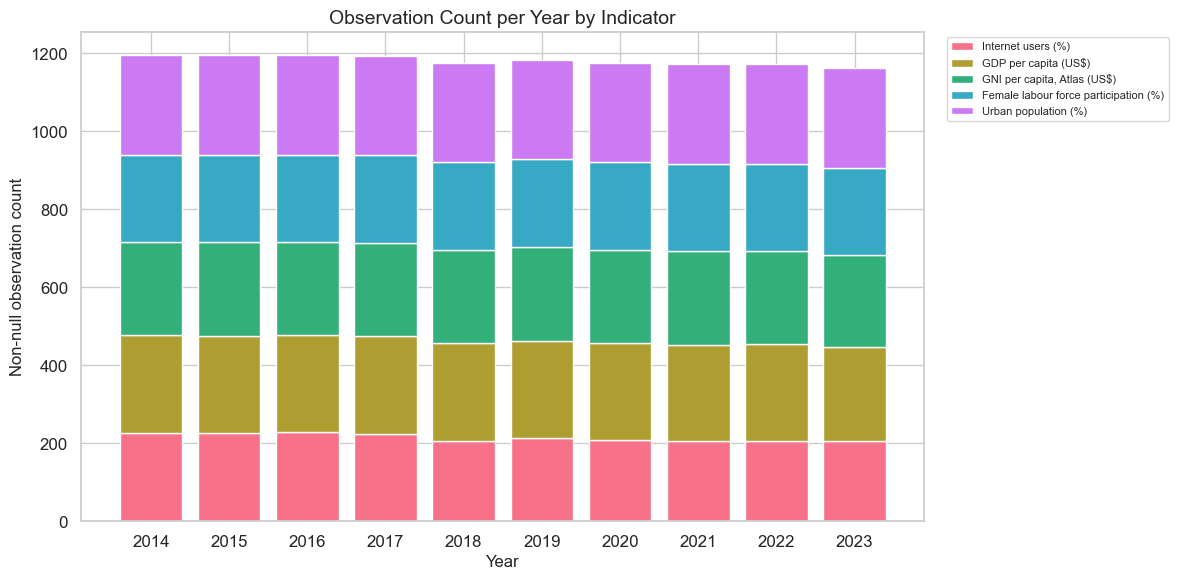

In [13]:
# Stacked bar — observation count per year, split by indicator
fig, ax = plt.subplots(figsize=(12, 6))

indicator_codes = [c for c in year_cov.columns
                  if c != "total_indicators_reported"]
bottom = np.zeros(len(year_cov))

palette = sns.color_palette("husl", len(indicator_codes))
for i, code in enumerate(indicator_codes):
    vals = year_cov[code].values
    ax.bar(year_cov.index.astype(str), vals, bottom=bottom,
           label=INDICATOR_LABELS.get(code, code), color=palette[i])
    bottom += vals

ax.set_xlabel("Year")
ax.set_ylabel("Non-null observation count")
ax.set_title("Observation Count per Year by Indicator")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Indicator Correlation Matrix
# ─────────────────────────────────────────────────────────────────────────────

corr = indicator_correlation(df)
corr

indicator_code,IT.NET.USER.ZS,NY.GDP.PCAP.CD,NY.GNP.PCAP.CD,SL.TLF.CACT.FE.ZS,SP.URB.TOTL.IN.ZS
indicator_code,,,,,
IT.NET.USER.ZS,1.0000,0.6205,0.6980,-0.0040,0.7175
NY.GDP.PCAP.CD,0.6205,1.0000,0.9880,0.1930,0.4443
NY.GNP.PCAP.CD,0.6980,0.9880,1.0000,0.1969,0.5794
SL.TLF.CACT.FE.ZS,-0.0040,0.1930,0.1969,1.0000,-0.0711
SP.URB.TOTL.IN.ZS,0.7175,0.4443,0.5794,-0.0711,1.0000


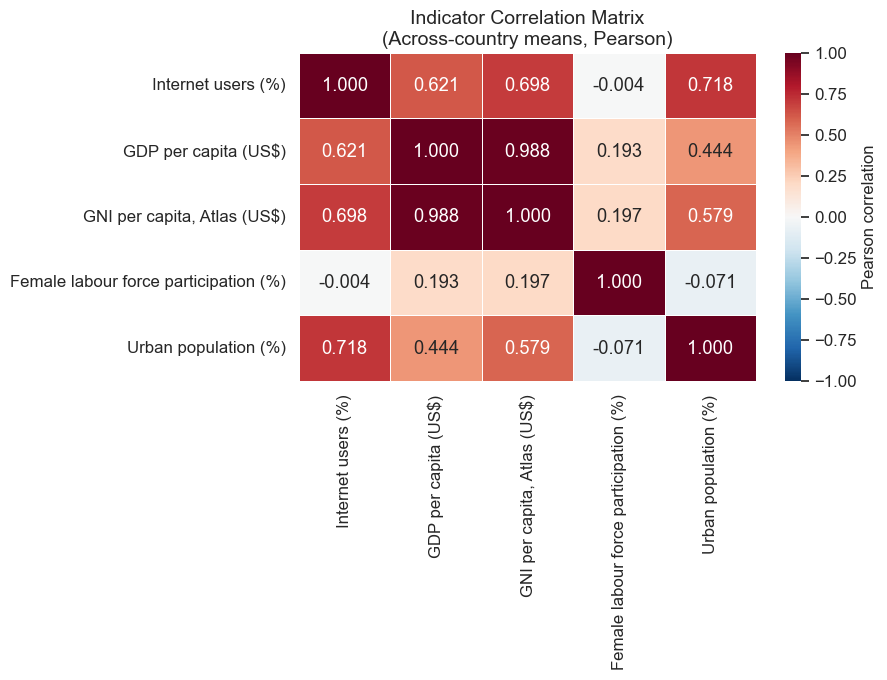

In [15]:
# Correlation heatmap
# Replace full indicator codes with short labels for readability
corr_labels = corr.copy()
corr_labels.index = [INDICATOR_LABELS.get(c, c) for c in corr_labels.index]
corr_labels.columns = [INDICATOR_LABELS.get(c, c) for c in corr_labels.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_labels, dtype=bool), k=1)
sns.heatmap(
    corr_labels,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Indicator Correlation Matrix\n(Across-country means, Pearson)")
plt.tight_layout()
plt.show()

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. Distribution Analysis
# ─────────────────────────────────────────────────────────────────────────────

dist = distribution_by_indicator(df)
dist

,n,mean,std,cv,min,q25,median,q75,max,iqr,skewness,kurtosis
indicator_code,,,,,,,,,,,,
NY.GDP.PCAP.CD,2481,17716.81,26664.21,1.5050,232.94,2322.89,6665.74,21912.15,256799.79,19589.26,3.2746,15.4984
NY.GNP.PCAP.CD,2387,15200.77,20346.01,1.3385,240.00,2220.00,6199.06,19080.00,134500.00,16860.00,2.0606,4.3648
SP.URB.TOTL.IN.ZS,2550,60.45,22.61,0.3741,13.13,42.48,61.00,78.75,100.00,36.27,-0.0564,-0.9386
IT.NET.USER.ZS,2153,57.38,28.36,0.4942,0.99,31.50,63.22,81.71,100.00,50.20,-0.3222,-1.1797
SL.TLF.CACT.FE.ZS,2246,50.26,14.94,0.2973,4.75,44.02,52.15,59.50,83.41,15.48,-0.6583,0.4589


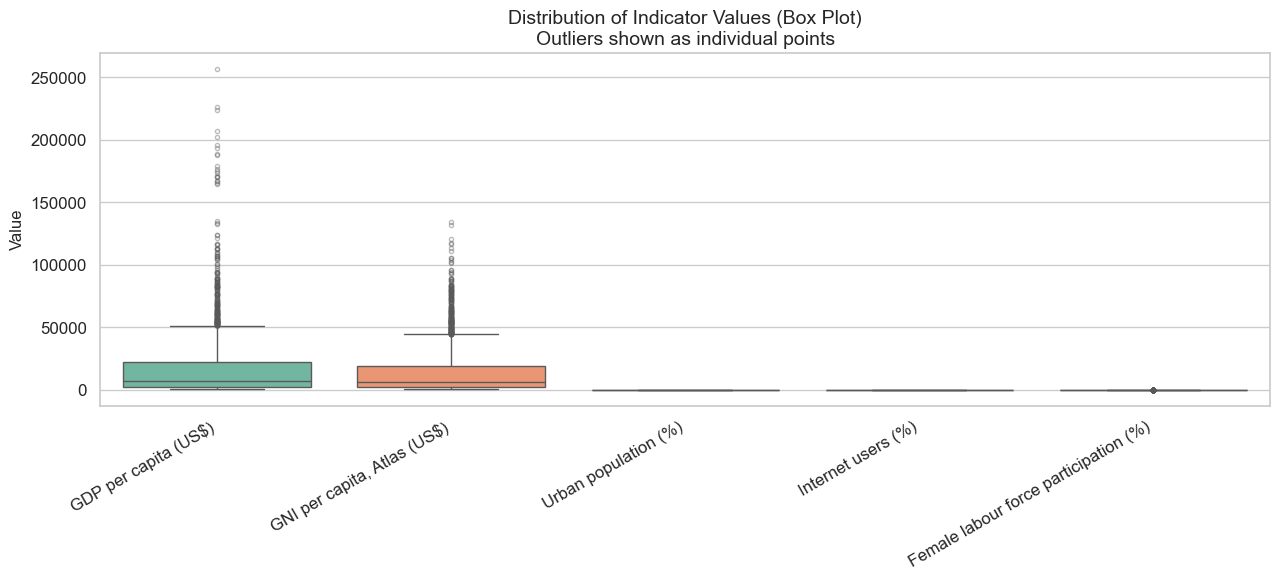

In [17]:
# Box plots per indicator — reveals outliers and skew
fig, ax = plt.subplots(figsize=(13, 6))

order = dist.index.tolist()
sns.boxplot(
    data=df,
    x="indicator_code",
    y="value",
    order=order,
    palette="Set2",
    showfliers=True,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    ax=ax,
)
ax.set_xticklabels([INDICATOR_LABELS.get(c, c) for c in order], rotation=30,
                   ha="right")
ax.set_xlabel("")
ax.set_ylabel("Value")
ax.set_title("Distribution of Indicator Values (Box Plot)\nOutliers shown as individual points")
plt.tight_layout()
plt.show()

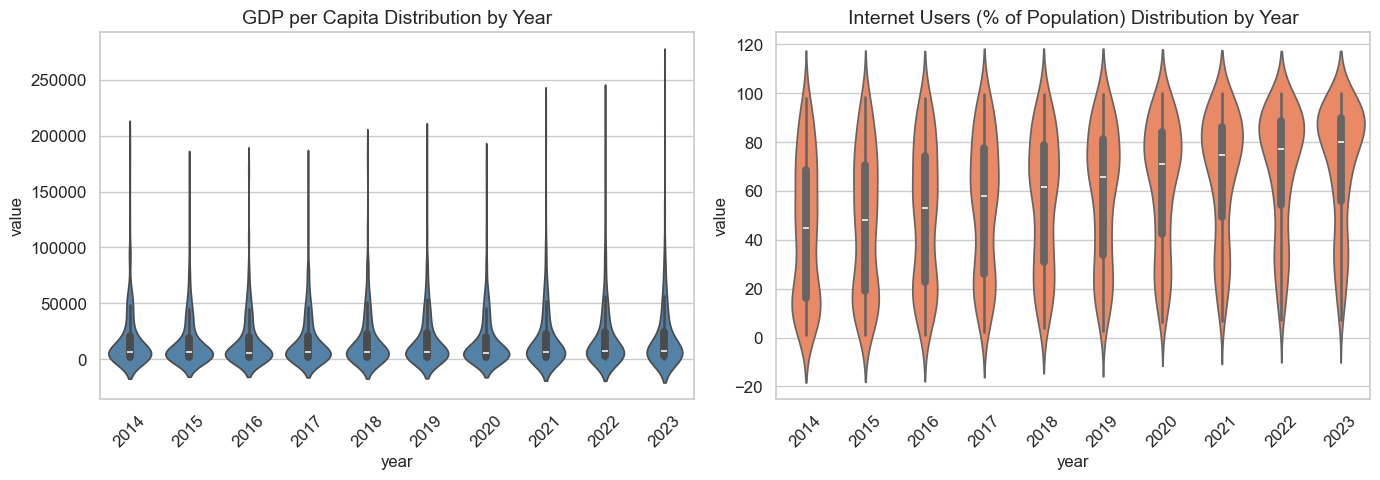

In [18]:
# Violin plots — show full distribution shape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: GDP per capita violin
gdp_df = df[df["indicator_code"] == "NY.GDP.PCAP.CD"].copy()
sns.violinplot(data=gdp_df, x="year", y="value", color="steelblue", ax=axes[0])
axes[0].set_title("GDP per Capita Distribution by Year")
axes[0].tick_params(axis="x", rotation=45)

# Right: Internet users violin
net_df = df[df["indicator_code"] == "IT.NET.USER.ZS"].copy()
sns.violinplot(data=net_df, x="year", y="value", color="coral", ax=axes[1])
axes[1].set_title("Internet Users (% of Population) Distribution by Year")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

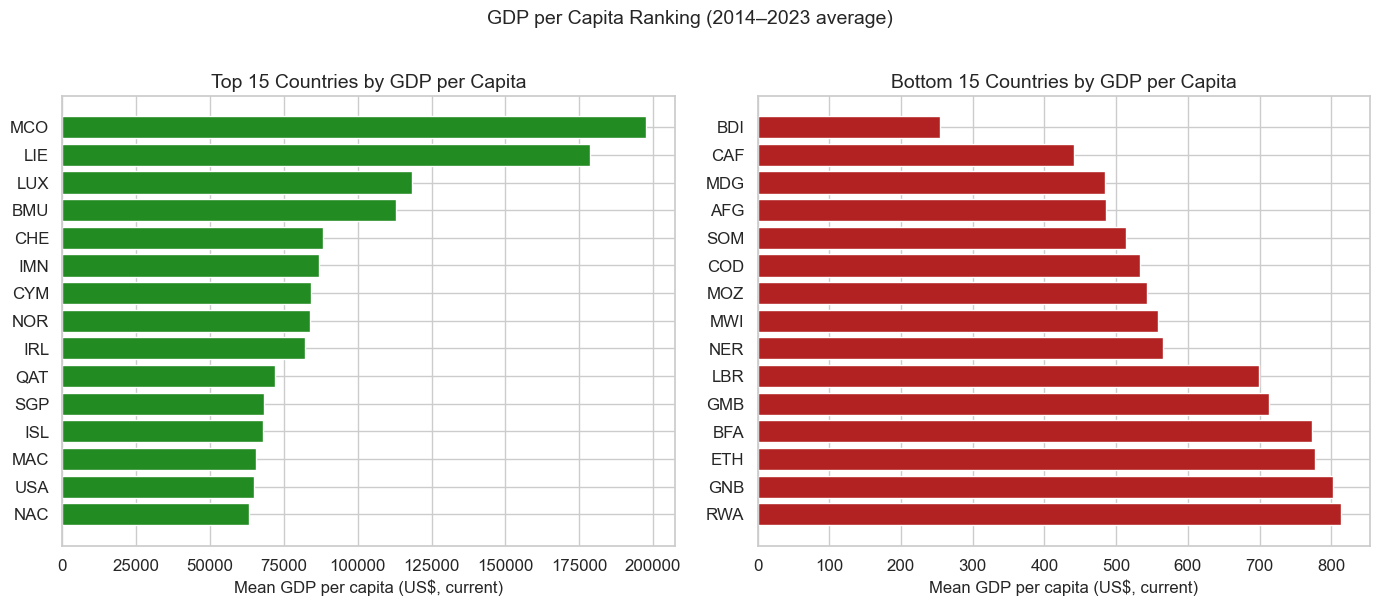


Top 15:


,country_iso3,country_name,mean_value,n_years,first_year,last_year
0,MCO,Monaco,197601.094306,10,2014,2023
1,LIE,Liechtenstein,178519.302589,10,2014,2023
2,LUX,Luxembourg,118463.275244,10,2014,2023
3,BMU,Bermuda,112986.659502,10,2014,2023
4,CHE,Switzerland,88085.880851,10,2014,2023
5,IMN,Isle of Man,86756.627516,9,2014,2022
6,CYM,Cayman Islands,84316.325337,10,2014,2023
7,NOR,Norway,83687.894121,10,2014,2023
8,IRL,Ireland,82269.453959,10,2014,2023
9,QAT,Qatar,72119.467814,10,2014,2023



Bottom 15:


,country_iso3,country_name,mean_value,n_years,first_year,last_year
0,BDI,Burundi,253.835050,10,2014,2023
1,CAF,Central African Republic,441.862694,10,2014,2023
2,MDG,Madagascar,484.359262,10,2014,2023
3,AFG,Afghanistan,486.441871,10,2014,2023
4,SOM,"Somalia, Fed. Rep.",513.358055,10,2014,2023
5,COD,Democratic Republic of the Congo,532.811329,10,2014,2023
6,MOZ,Mozambique,542.932823,10,2014,2023
7,MWI,Malawi,558.692518,10,2014,2023
8,NER,Niger,565.205858,10,2014,2023
9,LBR,Liberia,699.211966,10,2014,2023


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. Top & Bottom Countries
# ─────────────────────────────────────────────────────────────────────────────

# GDP per capita ranking
gdp_ranking = top_bottom(df, "NY.GDP.PCAP.CD", n=15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15
top_df = gdp_ranking["top"].head(15)
axes[0].barh(top_df["country_iso3"][::-1], top_df["mean_value"][::-1],
             color="forestgreen", edgecolor="white")
axes[0].set_xlabel("Mean GDP per capita (US$, current)")
axes[0].set_title("Top 15 Countries by GDP per Capita")

# Bottom 15
bottom_df = gdp_ranking["bottom"].head(15)
axes[1].barh(bottom_df["country_iso3"][::-1], bottom_df["mean_value"][::-1],
             color="firebrick", edgecolor="white")
axes[1].set_xlabel("Mean GDP per capita (US$, current)")
axes[1].set_title("Bottom 15 Countries by GDP per Capita")

plt.suptitle("GDP per Capita Ranking (2014–2023 average)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nTop 15:")
display(gdp_ranking["top"])
print("\nBottom 15:")
display(gdp_ranking["bottom"])

KeyError: 'country_iso3'

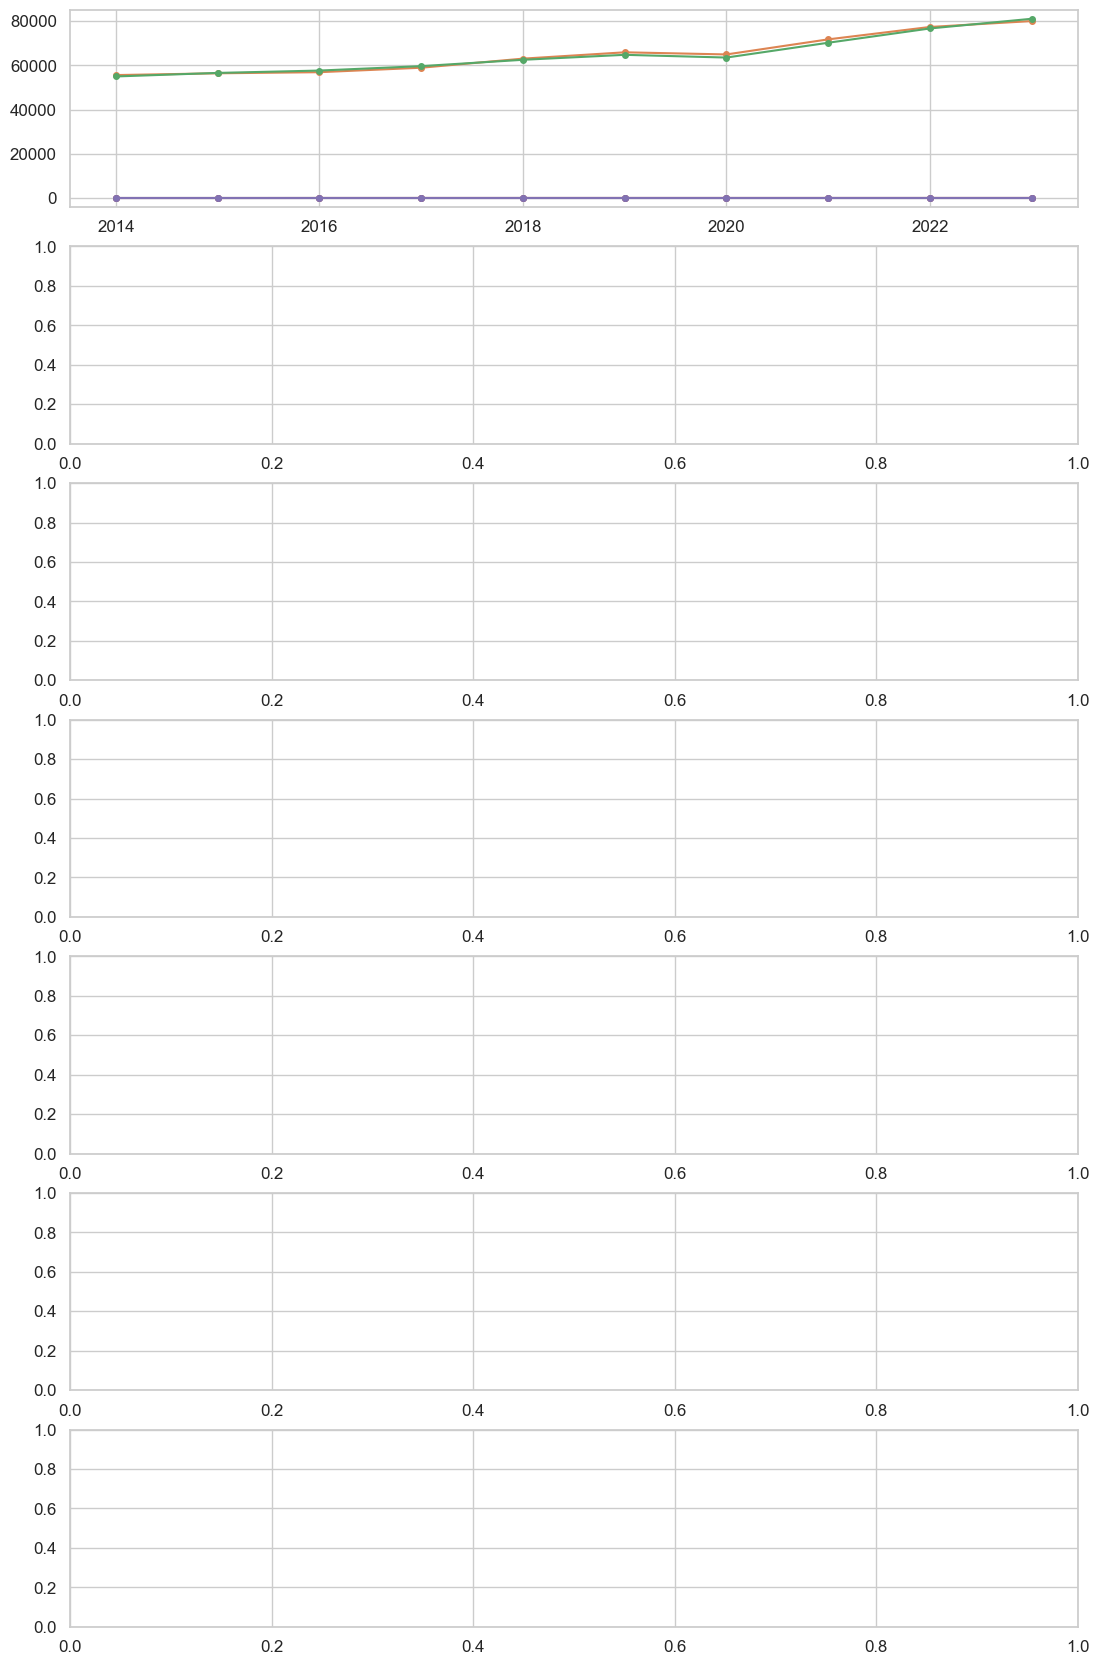

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. Time-Series Visualisation
# ─────────────────────────────────────────────────────────────────────────────

SAMPLE_COUNTRIES = ["USA", "CHN", "IND", "DEU", "BRA", "NGA", "JPN"]

fig, axes = plt.subplots(
    len(SAMPLE_COUNTRIES), 1,
    figsize=(13, 3 * len(SAMPLE_COUNTRIES)),
    sharex=False,
)

for i, iso3 in enumerate(SAMPLE_COUNTRIES):
    ax = axes[i]
    ts = time_series_data(df, iso3)

    if ts.empty:
        ax.set_title(f"{iso3} — No data found")
        continue

    for code in ts["indicator_code"].unique():
        sub = ts[ts["indicator_code"] == code]
        label = INDICATOR_LABELS.get(code, code)
        ax.plot(sub["year"], sub["value"], marker="o", markersize=4,
                label=label)

    country_name = ts["country_iso3"].iloc[0] if not ts.empty else iso3
    ax.set_title(f"{iso3}")
    ax.legend(fontsize=7, loc="upper left")
    ax.set_xlabel("Year")
    ax.set_ylabel("Value")

plt.suptitle("Indicator Time Series — Selected Countries (2014–2023)",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

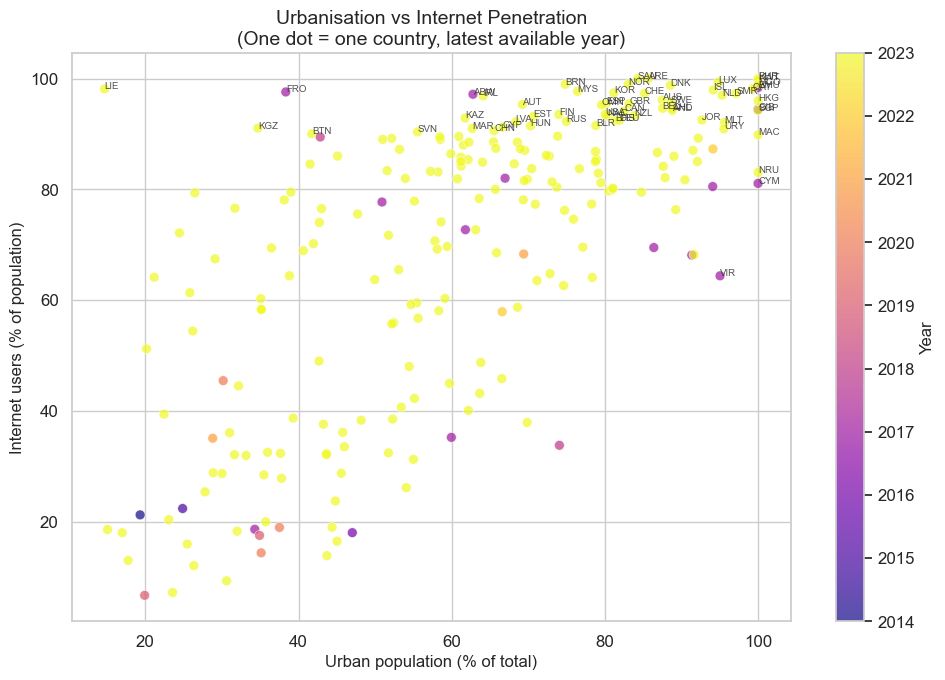

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. Urbanisation vs Internet Penetration (scatter plot)
# ─────────────────────────────────────────────────────────────────────────────

# Merge urbanisation and internet indicators into one wide DataFrame
urban = df[df["indicator_code"] == "SP.URB.TOTL.IN.ZS"]\
         .rename(columns={"value": "urban_pct"})\
         [["country_iso3", "year", "urban_pct"]]

internet = df[df["indicator_code"] == "IT.NET.USER.ZS"]\
            .rename(columns={"value": "internet_pct"})\
            [["country_iso3", "year", "internet_pct"]]

merged = urban.merge(internet, on=["country_iso3", "year"]).dropna()

# Take the most recent year for each country (latest available)
latest = merged.sort_values("year").groupby("country_iso3").last().reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    latest["urban_pct"],
    latest["internet_pct"],
    c=latest["year"],
    cmap="plasma",
    alpha=0.7,
    s=50,
    edgecolors="white",
    linewidths=0.5,
)
ax.set_xlabel("Urban population (% of total)")
ax.set_ylabel("Internet users (% of population)")
ax.set_title("Urbanisation vs Internet Penetration\n(One dot = one country, latest available year)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Year")

# Annotate outliers — countries with very high urbanisation or internet
outliers = latest[(latest["urban_pct"] > 95) | (latest["internet_pct"] > 90)]
for _, row in outliers.iterrows():
    ax.annotate(
        row["country_iso3"],
        (row["urban_pct"], row["internet_pct"]),
        fontsize=7, alpha=0.8,
    )

plt.tight_layout()
plt.show()

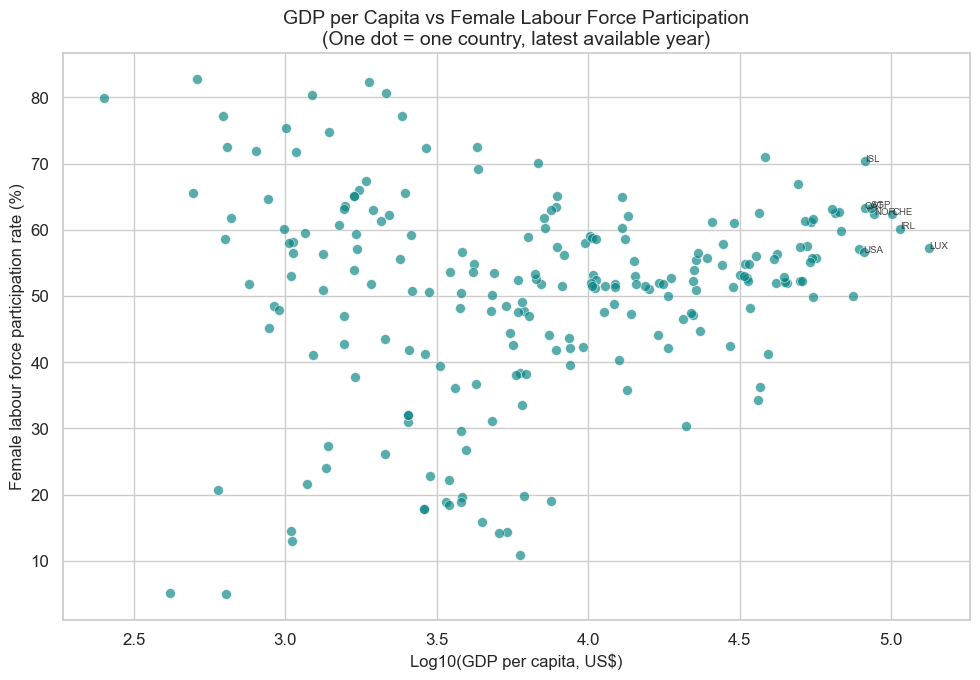

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. GDP vs Female Labour Force Participation (scatter plot)
# ─────────────────────────────────────────────────────────────────────────────

gdp = df[df["indicator_code"] == "NY.GDP.PCAP.CD"]\
       .rename(columns={"value": "gdp_pc"})\
       [["country_iso3", "year", "gdp_pc"]]

flfpr = df[df["indicator_code"] == "SL.TLF.CACT.FE.ZS"]\
         .rename(columns={"value": "flfpr"})\
         [["country_iso3", "year", "flfpr"]]

merged2 = gdp.merge(flfpr, on=["country_iso3", "year"]).dropna()
latest2 = merged2.sort_values("year").groupby("country_iso3").last().reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    np.log10(latest2["gdp_pc"] + 1),   # log-scale for GDP (very skewed)
    latest2["flfpr"],
    alpha=0.65,
    s=50,
    c="teal",
    edgecolors="white",
    linewidths=0.5,
)
ax.set_xlabel("Log10(GDP per capita, US$)")
ax.set_ylabel("Female labour force participation rate (%)")
ax.set_title("GDP per Capita vs Female Labour Force Participation\n"
             "(One dot = one country, latest available year)")

# Annotate notable countries
notable = latest2[(latest2["flfpr"] > 85) | (latest2["gdp_pc"] > 80000)]
for _, row in notable.iterrows():
    ax.annotate(
        row["country_iso3"],
        (np.log10(row["gdp_pc"] + 1), row["flfpr"]),
        fontsize=7, alpha=0.85,
    )

plt.tight_layout()
plt.show()

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# End of EDA Notebook
# ─────────────────────────────────────────────────────────────────────────────

print("EDA notebook complete.")
print(f"Panel: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Countries: {df['country_iso3'].nunique()}  |  "
      f"Years: {df['year'].min()}–{df['year'].max()}  |  "
      f"Indicators: {df['indicator_code'].nunique()}")

EDA notebook complete.
Panel: 11,817 rows × 5 columns
Countries: 255  |  Years: 2014–2023  |  Indicators: 5
